<a href="https://colab.research.google.com/github/adndrhmdn1/UTS-PMML/blob/main/2404220048_UTS_PMML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Prediksi Modern & Machine Learning



# Setup & Load Dataset

In [ ]:
import warnings, time, os
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
pd.set_option('display.width', 200)

In [ ]:
# Sumber utama: Kaggle (uciml/default-of-credit-card-clients-dataset), file UCI_Credit_Card.csv.
# Urutan percobaan: file lokal -> kagglehub -> salinan identik di GitHub.
CSV = 'UCI_Credit_Card.csv'
MIRROR = 'https://raw.githubusercontent.com/drchimes/UCI_Credit_Card.csv/main/UCI_Credit_Card.csv'

if not os.path.exists(CSV):
    try:
        import kagglehub
        p = kagglehub.dataset_download('uciml/default-of-credit-card-clients-dataset')
        CSV = os.path.join(p, 'UCI_Credit_Card.csv')
    except Exception as e:
        print('kagglehub gagal, memakai salinan GitHub:', type(e).__name__)
        import urllib.request
        urllib.request.urlretrieve(MIRROR, CSV)

df = pd.read_csv(CSV)
print('Sumber data:', CSV)
df.head()

100%|██████████| 0.98M/0.98M [00:00<00:00, 3.47MB/s]

Extracting files...
Sumber data: /root/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1/UCI_Credit_Card.csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,"20,000.0000",2,2,1,24,2,2,-1,-1,...,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,1
1,2,"120,000.0000",2,2,2,26,-1,2,0,0,...,"3,272.0000","3,455.0000","3,261.0000",0.0000,"1,000.0000","1,000.0000","1,000.0000",0.0000,"2,000.0000",1
2,3,"90,000.0000",2,2,2,34,0,0,0,0,...,"14,331.0000","14,948.0000","15,549.0000","1,518.0000","1,500.0000","1,000.0000","1,000.0000","1,000.0000","5,000.0000",0
3,4,"50,000.0000",2,2,1,37,0,0,0,0,...,"28,314.0000","28,959.0000","29,547.0000","2,000.0000","2,019.0000","1,200.0000","1,100.0000","1,069.0000","1,000.0000",0
4,5,"50,000.0000",1,2,1,57,-1,0,-1,0,...,"20,940.0000","19,146.0000","19,131.0000","2,000.0000","36,681.0000","10,000.0000","9,000.0000",689.0000,679.0000,0


## Data Understanding & Preparation


### 1 Dimensi, struktur, dan tipe data

In [ ]:
print('Dimensi dataset (baris, kolom):', df.shape)
df.info()

Dimensi dataset (baris, kolom): (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,"30,000.0000","15,000.5000","8,660.3984",1.0000,"7,500.7500","15,000.5000","22,500.2500","30,000.0000"
LIMIT_BAL,"30,000.0000","167,484.3227","129,747.6616","10,000.0000","50,000.0000","140,000.0000","240,000.0000","1,000,000.0000"
SEX,"30,000.0000",1.6037,0.4891,1.0000,1.0000,2.0000,2.0000,2.0000
EDUCATION,"30,000.0000",1.8531,0.7903,0.0000,1.0000,2.0000,2.0000,6.0000
MARRIAGE,"30,000.0000",1.5519,0.5220,0.0000,1.0000,2.0000,2.0000,3.0000
AGE,"30,000.0000",35.4855,9.2179,21.0000,28.0000,34.0000,41.0000,79.0000
PAY_0,"30,000.0000",-0.0167,1.1238,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_2,"30,000.0000",-0.1338,1.1972,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_3,"30,000.0000",-0.1662,1.1969,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_4,"30,000.0000",-0.2207,1.1691,-2.0000,-1.0000,0.0000,0.0000,8.0000


### 2 Variabel target, missing value, dan duplicate

In [ ]:
TARGET = 'default.payment.next.month'
print('Variabel target :', TARGET)
print('Jumlah missing value per kolom (total):', int(df.isna().sum().sum()))
print('Duplikat berdasarkan ID               :', int(df['ID'].duplicated().sum()))
print('Duplikat seluruh kolom selain ID      :', int(df.drop(columns='ID').duplicated().sum()))

Variabel target : default.payment.next.month
Jumlah missing value per kolom (total): 0
Duplikat berdasarkan ID               : 0
Duplikat seluruh kolom selain ID      : 35


# 3 Distribusi target

                            jumlah  persen (%)
default.payment.next.month                    
0                            23364     77.8800
1                             6636     22.1200


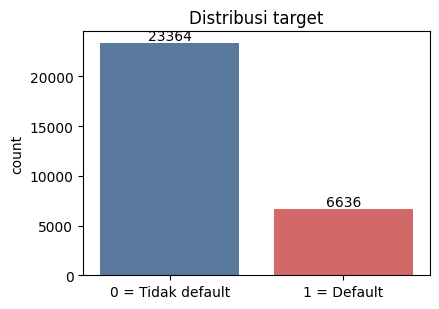

In [ ]:
vc = df[TARGET].value_counts().sort_index()
print(pd.DataFrame({'jumlah': vc, 'persen (%)': vc / len(df) * 100}))

fig, ax = plt.subplots(figsize=(4.5, 3.2))
sns.countplot(x=TARGET, data=df, ax=ax, palette=['#4C78A8', '#E45756'])
ax.set_xticklabels(['0 = Tidak default', '1 = Default']); ax.set_xlabel('')
ax.set_title('Distribusi target')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.savefig('fig_target.png', dpi=150); plt.show()

**Interpretasi:** target tidak seimbang (sekitar 78% tidak default vs 22% default). Karena itu *accuracy* saja akan menyesatkan
(model yang selalu menebak "tidak default" sudah mendapat ±78%), sehingga F1-score kelas default dipakai sebagai metrik utama.

### 4 Pemeriksaan nilai tidak sesuai / tidak wajar

In [ ]:
print('SEX        :', df['SEX'].value_counts().sort_index().to_dict(), '(dokumentasi: 1=pria, 2=wanita)')
print('EDUCATION  :', df['EDUCATION'].value_counts().sort_index().to_dict(), '(dokumentasi: 1-4; 0,5,6 tidak terdokumentasi)')
print('MARRIAGE   :', df['MARRIAGE'].value_counts().sort_index().to_dict(), '(dokumentasi: 1-3; 0 tidak terdokumentasi)')
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols = [f'BILL_AMT{i}' for i in range(1,7)]
amt_cols = [f'PAY_AMT{i}' for i in range(1,7)]
for c in pay_cols:
    print(c, sorted(df[c].unique()))
print()
print('Jumlah BILL_AMT negatif (kelebihan bayar) per kolom:'); print((df[bill_cols] < 0).sum().to_dict())
print('Jumlah PAY_AMT negatif :', int((df[amt_cols] < 0).sum().sum()))
print('AGE        : min', df['AGE'].min(), '| max', df['AGE'].max())
print('LIMIT_BAL  : min', df['LIMIT_BAL'].min(), '| max', df['LIMIT_BAL'].max())

SEX        : {1: 11888, 2: 18112} (dokumentasi: 1=pria, 2=wanita)
EDUCATION  : {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51} (dokumentasi: 1-4; 0,5,6 tidak terdokumentasi)
MARRIAGE   : {0: 54, 1: 13659, 2: 15964, 3: 323} (dokumentasi: 1-3; 0 tidak terdokumentasi)
PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), n

### 5 Predictor, target, dan train-test split

In [ ]:
df = df.rename(columns={'PAY_0': 'PAY_1'})
n_before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'ID']).reset_index(drop=True)
print(f'Baris sebelum/sesudah hapus duplikat: {n_before} -> {len(df)}')

y = df[TARGET]
X = df.drop(columns=['ID', TARGET])      # ID dikeluarkan dari predictor
print('Jumlah predictor:', X.shape[1])

# Split SEBELUM preprocessing yang bersifat 'belajar' dari data (scaling/encoding) -> mencegah leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi default  train: %.4f | test: %.4f' % (y_train.mean(), y_test.mean()))

Baris sebelum/sesudah hapus duplikat: 30000 -> 29965
Jumlah predictor: 23
Train: (23972, 23) | Test: (5993, 23)
Proporsi default  train: 0.2213 | test: 0.2213


### 6 Rencana preprocessing (dipakai di Experiment 2 dst.)


In [ ]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [c for c in X.columns if c not in cat_cols]

def recode_categories(d):
    d = d.copy()
    d['EDUCATION'] = d['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
    d['MARRIAGE']  = d['MARRIAGE'].replace({0: 3})
    return d

def make_preprocessor():
    return Pipeline([
        ('recode', FunctionTransformer(recode_categories)),
        ('encode_scale', ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', StandardScaler(), num_cols)])),
    ])

print('Kolom kategorikal :', cat_cols)
print('Kolom numerik     :', len(num_cols), 'kolom')

Kolom kategorikal : ['SEX', 'EDUCATION', 'MARRIAGE']
Kolom numerik     : 20 kolom


## Fungsi evaluasi (prosedur yang sama untuk semua eksperimen)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
RESULTS = {}      # key -> dict hasil
FITTED  = {}      # key -> model terlatih

def evaluate(key, exp, name, model):
    t0 = time.time()
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)   # 5-fold CV pada training set
    model.fit(X_train, y_train)
    pred = model.predict(X_test)                                                       # evaluasi pada test set
    r = {'Experiment': exp, 'Model': name,
         'CV F1': cv_f1.mean(), 'CV F1 Std': cv_f1.std(),
         'Test Accuracy':  accuracy_score(y_test, pred),
         'Test Precision': precision_score(y_test, pred, zero_division=0),
         'Test Recall':    recall_score(y_test, pred),
         'Test F1':        f1_score(y_test, pred),
         'Waktu (s)': time.time() - t0}
    RESULTS[key] = r; FITTED[key] = model
    return r

def show(keys):
    cols = ['Experiment','Model','CV F1','CV F1 Std','Test Accuracy','Test Precision','Test Recall','Test F1']
    return pd.DataFrame([RESULTS[k] for k in keys])[cols]

## Experiment 1 — Baseline Model
Logistic Regression pada data **tanpa preprocessing tambahan** (fitur mentah apa adanya, hanya ID yang dibuang dan duplikat dihapus).

In [ ]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
evaluate('exp1', 'Exp 1', 'Logistic Regression (baseline, raw)', baseline)
show(['exp1'])

,Experiment,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Exp 1,"Logistic Regression (baseline, raw)",0.3288,0.0284,0.8039,0.6674,0.2270,0.3388


## Experiment 2 — Preprocessing
Logistic Regression dibangun ulang dengan pipeline preprocessing (recode kategori + One-Hot Encoding + Standard Scaling).
Karena target tidak seimbang, ditambahkan satu varian dengan `class_weight='balanced'`; pemilihan varian berdasarkan **CV F1** (bukan test set).

In [ ]:
lr_prep = Pipeline([('prep', make_preprocessor()),
                    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
lr_prep_bal = Pipeline([('prep', make_preprocessor()),
                        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])

evaluate('exp2a', 'Exp 2a', 'LogReg + encoding + scaling', lr_prep)
evaluate('exp2b', 'Exp 2b', 'LogReg + encoding + scaling + class_weight', lr_prep_bal)
show(['exp1', 'exp2a', 'exp2b'])

,Experiment,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Exp 1,"Logistic Regression (baseline, raw)",0.3288,0.0284,0.8039,0.6674,0.2270,0.3388
1,Exp 2a,LogReg + encoding + scaling,0.3576,0.0112,0.8136,0.7267,0.2526,0.3749
2,Exp 2b,LogReg + encoding + scaling + class_weight,0.4778,0.0108,0.6828,0.3723,0.6320,0.4685


In [ ]:
# Pilih varian preprocessing berdasarkan CV F1 (data training saja)
best2 = 'exp2a' if RESULTS['exp2a']['CV F1'] >= RESULTS['exp2b']['CV F1'] else 'exp2b'
CLASS_WEIGHT = None if best2 == 'exp2a' else 'balanced'
RESULTS['exp2'] = RESULTS[best2]; FITTED['exp2'] = FITTED[best2]
print('Varian preprocessing terpilih :', RESULTS[best2]['Model'])
print('class_weight yang dipakai di eksperimen berikutnya:', CLASS_WEIGHT)

d = pd.DataFrame({'Exp 1 (baseline)': RESULTS['exp1'], 'Exp 2 (terpilih)': RESULTS['exp2']}).T[
    ['CV F1','Test Accuracy','Test Precision','Test Recall','Test F1']].astype(float)
d.loc['Perubahan'] = d.loc['Exp 2 (terpilih)'] - d.loc['Exp 1 (baseline)']
d

Varian preprocessing terpilih : LogReg + encoding + scaling + class_weight
class_weight yang dipakai di eksperimen berikutnya: balanced


,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Exp 1 (baseline),0.3288,0.8039,0.6674,0.2270,0.3388
Exp 2 (terpilih),0.4778,0.6828,0.3723,0.6320,0.4685
Perubahan,0.1490,-0.1211,-0.2951,0.4050,0.1298


In [ ]:
dF1 = RESULTS['exp2']['Test F1'] - RESULTS['exp1']['Test F1']
dCV = RESULTS['exp2']['CV F1']   - RESULTS['exp1']['CV F1']
print(f'Perubahan CV F1   : {dCV:+.4f}')
print(f'Perubahan Test F1 : {dF1:+.4f}')
print('Kesimpulan Exp 2  :', 'preprocessing MENINGKATKAN performa (F1).' if dF1 > 0 and dCV > 0 else
      'preprocessing TIDAK memberi peningkatan F1 yang konsisten.')

Perubahan CV F1   : +0.1490
Perubahan Test F1 : +0.1298
Kesimpulan Exp 2  : preprocessing MENINGKATKAN performa (F1).


## Experiment 3 — Model Comparison
Logistic Regression, Decision Tree, dan Random Forest, dengan **preprocessing dan prosedur evaluasi yang sama**
(hyperparameter default, kecuali `class_weight` sesuai keputusan Experiment 2).

In [ ]:
def make_model(name, cw=CLASS_WEIGHT):
    if name == 'Logistic Regression':
        clf = LogisticRegression(max_iter=1000, class_weight=cw, random_state=RANDOM_STATE)
    elif name == 'Decision Tree':
        clf = DecisionTreeClassifier(class_weight=cw, random_state=RANDOM_STATE)
    elif name == 'Random Forest':
        clf = RandomForestClassifier(n_estimators=200, class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor()), ('clf', clf)])

MODEL_NAMES = ['Logistic Regression', 'Decision Tree', 'Random Forest']
for i, n in enumerate(MODEL_NAMES):
    evaluate(f'exp3_{n}', 'Exp 3', n, make_model(n))
exp3 = show([f'exp3_{n}' for n in MODEL_NAMES])
exp3

,Experiment,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Exp 3,Logistic Regression,0.4778,0.0108,0.6828,0.3723,0.6320,0.4685
1,Exp 3,Decision Tree,0.3894,0.0157,0.7248,0.3790,0.3816,0.3803
2,Exp 3,Random Forest,0.4579,0.0140,0.8109,0.6365,0.3394,0.4427


In [ ]:
# Model terbaik ditentukan dari CV F1 (data training), bukan dari asumsi dan bukan dari test set.
best_name = exp3.sort_values('CV F1', ascending=False).iloc[0]['Model']
RESULTS['exp3'] = RESULTS[f'exp3_{best_name}']; FITTED['exp3'] = FITTED[f'exp3_{best_name}']
print('Model terbaik Experiment 3 (CV F1 tertinggi):', best_name)
print('Urutan berdasarkan Test F1:', exp3.sort_values('Test F1', ascending=False)['Model'].tolist())

Model terbaik Experiment 3 (CV F1 tertinggi): Logistic Regression
Urutan berdasarkan Test F1: ['Logistic Regression', 'Random Forest', 'Decision Tree']


## Experiment 4 — Hyperparameter Tuning (GridSearchCV, 5-fold CV, scoring = F1)
Model terbaik dari Experiment 3 dituning. Grid disiapkan untuk ketiga model; yang dijalankan hanya milik model terbaik.

In [ ]:
PARAM_GRIDS = {
    'Logistic Regression': {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
                            'clf__class_weight': [None, 'balanced']},
    'Decision Tree': {'clf__max_depth': [3, 5, 7, 10],
                      'clf__min_samples_leaf': [1, 20, 50],
                      'clf__criterion': ['gini', 'entropy']},
    'Random Forest': {'clf__max_depth': [6, 10, None],
                      'clf__min_samples_leaf': [1, 10, 30],
                      'clf__max_features': ['sqrt', 0.5]},
}
grid = PARAM_GRIDS[best_name]
print('Model yang dituning :', best_name)
print('Hyperparameter yang diuji:')
for k, v in grid.items(): print('  ', k, '->', v)

t0 = time.time()
gs = GridSearchCV(make_model(best_name), grid, scoring='f1', cv=cv, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)
print(f'\nWaktu grid search: {time.time()-t0:.0f} detik | jumlah kombinasi: {len(gs.cv_results_["params"])}')
print('Kombinasi terbaik :', gs.best_params_)
print('Best CV F1-score  : %.4f' % gs.best_score_)

Model yang dituning : Logistic Regression
Hyperparameter yang diuji:
   clf__C -> [0.001, 0.01, 0.1, 1, 10, 100]
   clf__class_weight -> [None, 'balanced']



Waktu grid search: 4 detik | jumlah kombinasi: 12
Kombinasi terbaik : {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
Best CV F1-score  : 0.4797


In [ ]:
pred = gs.best_estimator_.predict(X_test)
RESULTS['exp4'] = {'Experiment': 'Exp 4', 'Model': f'{best_name} (tuned)',
    'CV F1': gs.best_score_, 'CV F1 Std': gs.cv_results_['std_test_score'][gs.best_index_],
    'Test Accuracy': accuracy_score(y_test, pred), 'Test Precision': precision_score(y_test, pred, zero_division=0),
    'Test Recall': recall_score(y_test, pred), 'Test F1': f1_score(y_test, pred)}
FITTED['exp4'] = gs.best_estimator_

cmp4 = pd.DataFrame({'Sebelum tuning': RESULTS['exp3'], 'Setelah tuning': RESULTS['exp4']}).T[
    ['CV F1','Test Accuracy','Test Precision','Test Recall','Test F1']].astype(float)
cmp4.loc['Perubahan'] = cmp4.loc['Setelah tuning'] - cmp4.loc['Sebelum tuning']
cmp4

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Sebelum tuning,0.4778,0.6828,0.3723,0.6320,0.4685
Setelah tuning,0.4797,0.6878,0.3774,0.6327,0.4728
Perubahan,0.0018,0.0050,0.0051,0.0008,0.0043


In [ ]:
top = pd.DataFrame(gs.cv_results_)[['params','mean_test_score','std_test_score','rank_test_score']].sort_values('rank_test_score').head(5)
top

,params,mean_test_score,std_test_score,rank_test_score
3,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.4797,0.0087,1
5,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",0.4789,0.0112,2
7,"{'clf__C': 1, 'clf__class_weight': 'balanced'}",0.4778,0.0108,3
9,"{'clf__C': 10, 'clf__class_weight': 'balanced'}",0.4778,0.0107,4
11,"{'clf__C': 100, 'clf__class_weight': 'balanced'}",0.4778,0.0107,5


## Experiment 5 — Advanced Model: XGBoost
Gradient boosting (XGBoost) dengan preprocessing dan prosedur evaluasi yang sama. Hyperparameter ditetapkan moderat (tidak dituning)
agar perbandingan dengan Experiment 4 tetap adil dan sederhana. Bila `class_weight='balanced'` dipakai, padanannya di XGBoost adalah `scale_pos_weight` (rasio negatif:positif **dari data training saja**).

In [ ]:
spw = (y_train == 0).sum() / (y_train == 1).sum() if CLASS_WEIGHT == 'balanced' else 1.0
print('scale_pos_weight =', round(spw, 3))
xgb = Pipeline([('prep', make_preprocessor()),
                ('clf', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
                                      colsample_bytree=0.8, scale_pos_weight=spw, eval_metric='logloss',
                                      random_state=RANDOM_STATE, n_jobs=-1))])
evaluate('exp5', 'Exp 5', 'XGBoost', xgb)
show(['exp5'])

scale_pos_weight = 3.52


,Experiment,Model,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
0,Exp 5,XGBoost,0.5384,0.0090,0.7565,0.4629,0.6259,0.5322


In [ ]:
cmp5 = pd.DataFrame({'Terbaik Exp 4': RESULTS['exp4'], 'Exp 5 (XGBoost)': RESULTS['exp5']}).T[
    ['CV F1','Test Accuracy','Test Precision','Test Recall','Test F1']].astype(float)
cmp5.loc['Perubahan'] = cmp5.loc['Exp 5 (XGBoost)'] - cmp5.loc['Terbaik Exp 4']
cmp5

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Terbaik Exp 4,0.4797,0.6878,0.3774,0.6327,0.4728
Exp 5 (XGBoost),0.5384,0.7565,0.4629,0.6259,0.5322
Perubahan,0.0587,0.0687,0.0855,-0.0068,0.0594


## Ringkasan Seluruh Eksperimen

In [ ]:
order = [('exp1','1','Baseline (Logistic Regression, data mentah)'),
         ('exp2','2','Baseline + Preprocessing'),
         ('exp3','3','Model Comparison (terbaik): ' + best_name),
         ('exp4','4','Tuned Model: ' + best_name),
         ('exp5','5','Advanced Model: XGBoost')]
rows = []
for k, n, label in order:
    r = RESULTS[k]
    rows.append({'Experiment': n, 'Model': label, 'CV F1': r['CV F1'], 'Test Accuracy': r['Test Accuracy'],
                 'Test Precision': r['Test Precision'], 'Test Recall': r['Test Recall'], 'Test F1': r['Test F1']})
summary = pd.DataFrame(rows)
summary.to_csv('results_summary.csv', index=False)
exp3.to_csv('results_exp3_all_models.csv', index=False)
summary

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,"Baseline (Logistic Regression, data mentah)",0.3288,0.8039,0.6674,0.2270,0.3388
1,2,Baseline + Preprocessing,0.4778,0.6828,0.3723,0.6320,0.4685
2,3,Model Comparison (terbaik): Logistic Regression,0.4778,0.6828,0.3723,0.6320,0.4685
3,4,Tuned Model: Logistic Regression,0.4797,0.6878,0.3774,0.6327,0.4728
4,5,Advanced Model: XGBoost,0.5384,0.7565,0.4629,0.6259,0.5322


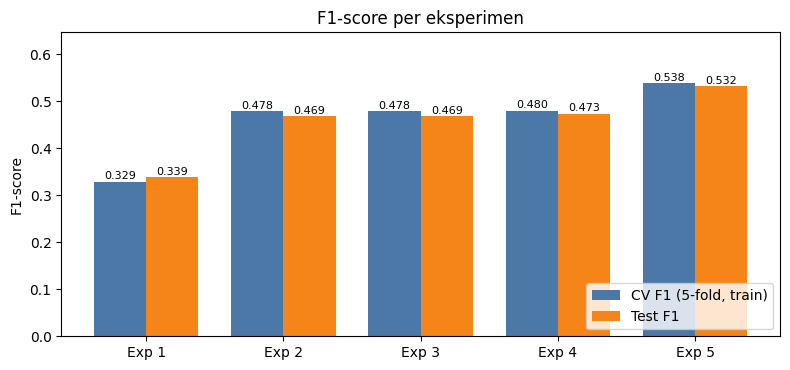

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(summary)); w = 0.38
ax.bar(x - w/2, summary['CV F1'], w, label='CV F1 (5-fold, train)', color='#4C78A8')
ax.bar(x + w/2, summary['Test F1'], w, label='Test F1', color='#F58518')
ax.set_xticks(x); ax.set_xticklabels([f'Exp {n}' for n in summary['Experiment']])
ax.set_ylabel('F1-score'); ax.set_title('F1-score per eksperimen'); ax.legend(loc='lower right')
ax.set_ylim(0, max(summary[['CV F1','Test F1']].max()) * 1.2)
for i, (a, b) in enumerate(zip(summary['CV F1'], summary['Test F1'])):
    ax.text(i - w/2, a + 0.005, f'{a:.3f}', ha='center', fontsize=8); ax.text(i + w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('fig_f1_summary.png', dpi=150); plt.show()

## Analisis Otomatis & Pemilihan Model Final

In [ ]:
R = RESULTS
print('P1 Preprocessing   : CV F1 %.4f -> %.4f | Test F1 %.4f -> %.4f' % (R['exp1']['CV F1'], R['exp2']['CV F1'], R['exp1']['Test F1'], R['exp2']['Test F1']))
print('P2 Model terbaik Exp 3 (CV F1):', best_name, '| CV F1 = %.4f | Test F1 = %.4f' % (R['exp3']['CV F1'], R['exp3']['Test F1']))
print('P3 Tuning          : CV F1 %.4f -> %.4f | Test F1 %.4f -> %.4f' % (R['exp3']['CV F1'], R['exp4']['CV F1'], R['exp3']['Test F1'], R['exp4']['Test F1']))
print('P4 Advanced        : Exp 4 Test F1 %.4f vs XGBoost Test F1 %.4f | CV F1 %.4f vs %.4f' % (R['exp4']['Test F1'], R['exp5']['Test F1'], R['exp4']['CV F1'], R['exp5']['CV F1']))

# Model final: dipilih berdasarkan CV F1 (tidak 'mengintip' test set); selisih sangat kecil (<0.002) -> pilih model lebih sederhana.
cands = {'exp3': 1, 'exp4': 1, 'exp5': 2}     # angka = tingkat kompleksitas (kecil = lebih sederhana)
best_cv = max(R[k]['CV F1'] for k in cands)
close = [k for k in cands if best_cv - R[k]['CV F1'] < 0.002]
final_key = sorted(close, key=lambda k: (cands[k], -R[k]['CV F1']))[0]
print('\nP5 Model final    :', R[final_key]['Model'], f'(dari {final_key})')
print('   CV F1 = %.4f | Test: Acc %.4f, Prec %.4f, Rec %.4f, F1 %.4f' % (
    R[final_key]['CV F1'], R[final_key]['Test Accuracy'], R[final_key]['Test Precision'], R[final_key]['Test Recall'], R[final_key]['Test F1']))

P1 Preprocessing   : CV F1 0.3288 -> 0.4778 | Test F1 0.3388 -> 0.4685
P2 Model terbaik Exp 3 (CV F1): Logistic Regression | CV F1 = 0.4778 | Test F1 = 0.4685
P3 Tuning          : CV F1 0.4778 -> 0.4797 | Test F1 0.4685 -> 0.4728
P4 Advanced        : Exp 4 Test F1 0.4728 vs XGBoost Test F1 0.5322 | CV F1 0.4797 vs 0.5384

P5 Model final    : XGBoost (dari exp5)
   CV F1 = 0.5384 | Test: Acc 0.7565, Prec 0.4629, Rec 0.6259, F1 0.5322
